# Static-support telemetry

A reproducible notebook analysis of one saved MuJoCo rollout. The simulator measures; this notebook interrogates the saved trace.

## tl;dr

This notebook loads one explicit telemetry artifact, validates its schema, and plots contact loads, support margin, and attitude without rerunning MuJoCo. Its outputs describe that artifact only; they are not a population-level stability conclusion.

## Context & Methods

The input is produced by `experiments/2026-08-11-static-support-centered-ballast/static_support.py --artifact …`. It records a fixed rollout at a 10 Hz telemetry cadence.

### Key assumptions

- The artifact uses schema version 1.
- The saved rollout is a traceable experiment output; this notebook does not modify its physics or infer missing samples.
- A single trace is an inspection aid, not an estimate over seeds or scenarios.

In [1]:
# 1. Locate and load one stored rollout
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'experiments').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise RuntimeError('Run this notebook from inside the robotics-test-bench checkout.')


REPOSITORY_ROOT = find_repository_root(Path.cwd().resolve())
ARTIFACT_PATH = REPOSITORY_ROOT / 'results/static-support/default.json'

if not ARTIFACT_PATH.exists():
    raise FileNotFoundError(
        'Generate the input first:\n'
        'python3 experiments/2026-08-11-static-support-centered-ballast/static_support.py '
        '--duration 2 --artifact results/static-support/default.json '
        '--run-id static-support-default'
    )

artifact = json.loads(ARTIFACT_PATH.read_text())
print(f'Loaded: {ARTIFACT_PATH.relative_to(REPOSITORY_ROOT)}')
print(f"Experiment: {artifact['experiment']['id']}")
print(f"Run: {artifact['run']['id']}")

Loaded: results/static-support/default.json
Experiment: 2026-08-11-static-support-centered-ballast
Run: static-support-default


## Data

In [2]:
# 2. Validate the artifact contract and inspect its bounds
required_top_level = {'schema_version', 'artifact_type', 'experiment', 'model', 'run', 'samples', 'summary'}
missing = required_top_level.difference(artifact)
assert not missing, f'Missing top-level fields: {sorted(missing)}'
assert artifact['schema_version'] == 1
assert artifact['artifact_type'] == 'robotics-test-bench.telemetry'
assert artifact['samples'], 'The artifact must contain at least one telemetry sample.'

required_sample_fields = {'time', 'normal_loads', 'support_margin_metres', 'roll_degrees', 'pitch_degrees'}
missing_sample_fields = required_sample_fields.difference(artifact['samples'][0])
assert not missing_sample_fields, f'Missing sample fields: {sorted(missing_sample_fields)}'

first_sample, last_sample = artifact['samples'][0], artifact['samples'][-1]
print(f"Samples: {len(artifact['samples'])}")
print(f"Time span: {first_sample['time']:.3f} s to {last_sample['time']:.3f} s")
print(f"MuJoCo timestep: {artifact['model']['timestep_seconds']:.3f} s")
print(f"Termination: {artifact['run']['termination']['reason']}")

Samples: 21
Time span: 0.000 s to 2.000 s
MuJoCo timestep: 0.002 s
Termination: duration_reached


## Results

In [3]:
# 3. Prepare time-aligned channels
samples = artifact['samples']
time_seconds = np.array([sample['time'] for sample in samples])
foot_names = sorted(samples[0]['normal_loads'])
normal_loads = {
    foot_name: np.array([sample['normal_loads'][foot_name] for sample in samples])
    for foot_name in foot_names
}
support_margin_metres = np.array([
    np.nan if sample['support_margin_metres'] is None else sample['support_margin_metres']
    for sample in samples
])
roll_degrees = np.array([sample['roll_degrees'] for sample in samples])
pitch_degrees = np.array([sample['pitch_degrees'] for sample in samples])

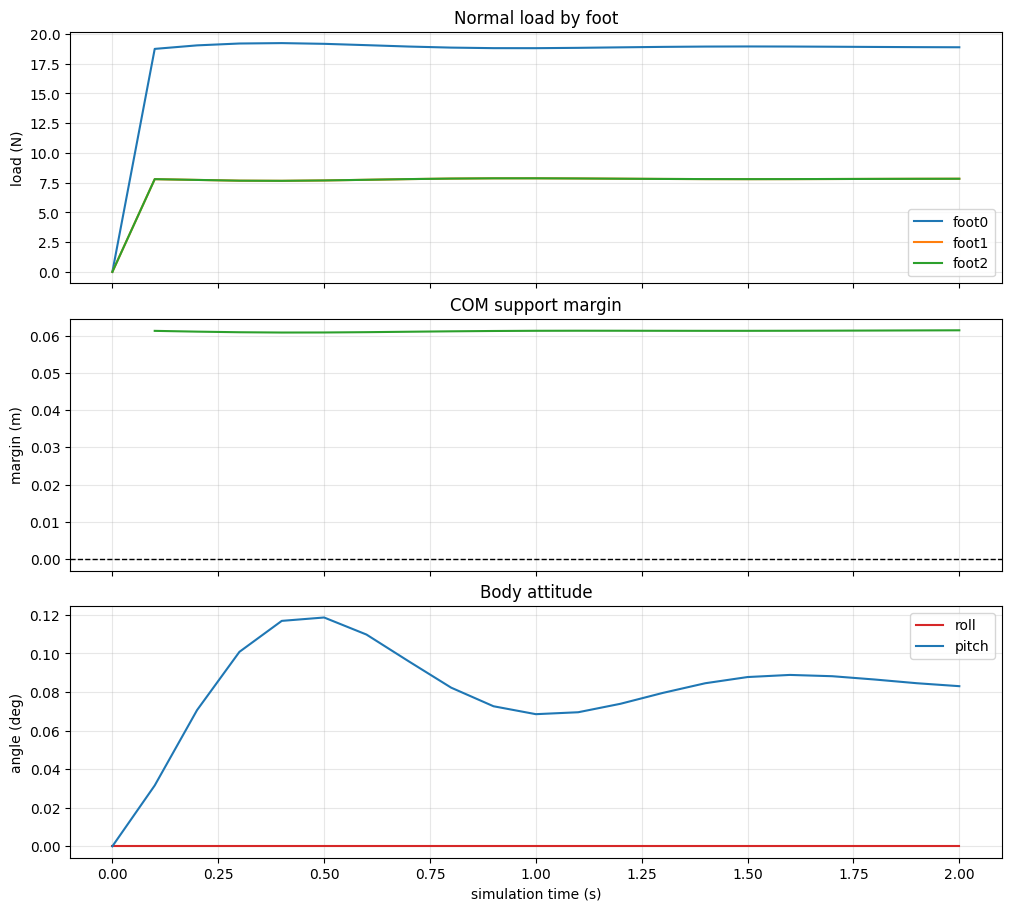

In [4]:
# 4. Plot the contact, support, and attitude evidence
figure, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True, layout='constrained')

for foot_name, load_newtons in normal_loads.items():
    axes[0].plot(time_seconds, load_newtons, label=foot_name)
axes[0].set(title='Normal load by foot', ylabel='load (N)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(time_seconds, support_margin_metres, color='tab:green')
axes[1].axhline(0.0, color='black', linewidth=1, linestyle='--')
axes[1].set(title='COM support margin', ylabel='margin (m)')
axes[1].grid(alpha=0.3)

axes[2].plot(time_seconds, roll_degrees, label='roll', color='tab:red')
axes[2].plot(time_seconds, pitch_degrees, label='pitch', color='tab:blue')
axes[2].set(title='Body attitude', xlabel='simulation time (s)', ylabel='angle (deg)')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.show()

In [5]:
# 5. Report bounded descriptive checks for this one artifact
descriptive_checks = {
    'sample_count': len(samples),
    'minimum_support_margin_metres': float(np.nanmin(support_margin_metres)),
    'maximum_abs_roll_degrees': float(np.max(np.abs(roll_degrees))),
    'maximum_abs_pitch_degrees': float(np.max(np.abs(pitch_degrees))),
    'minimum_normal_load_newtons': float(min(load.min() for load in normal_loads.values())),
}
descriptive_checks

{'sample_count': 21,
 'minimum_support_margin_metres': 0.060805003682615,
 'maximum_abs_roll_degrees': 3.296046778121482e-14,
 'maximum_abs_pitch_degrees': 0.11861783993258534,
 'minimum_normal_load_newtons': 0.0}

## Takeaways

- This is a repeatable analysis of one saved rollout: changing the notebook does not change the simulator trace.
- The next physical conclusion still needs an explicit predicted treatment and a reproducible experiment.
- To compare conditions, generate separately named artifacts with their input parameters preserved, then load them together in a follow-up notebook.